# 0_11 — Reaction conditions: distributions per peptidase, outliers, and what can be normalised

## Scope

The assay conditions behind a kinetic measurement are a property of the **kinetic
extraction**, not of any later join, so this notebook depends on nothing but
BRENDA and the MEROPS metadata. It parses the conditions, shows their
distributions, states an exclusion rule, works out what a thermodynamic
normalisation could be worth, and emits the condition-annotated table that
`0_15` consumes when it builds the analysis datasets.

One question that belongs to conditions is deliberately **not** asked here:
whether filtering on conditions sharpens the relation between the window score
and the measured rate. That question needs a score, a score needs the join, and
the join happens in `0_15`. Asking it here would make a notebook in series 0
depend on one further down, which is exactly the inversion this reordering
removed. It belongs in series 2, where the relation lives.

## A parsing defect, found and fixed

BRENDA records conditions in a free-text comment, not in a field. A permissive
pattern for a temperature matches the residue number of a **mutation code**: in

> `mutant enzyme I99C, at pH 6.8 and 25°C`

the substring `99C` is an isoleucine-to-cysteine substitution at position 99, not
an assay at 99 °C. An earlier version of this notebook recorded that entry at
99 °C; twenty-eight entries were assigned a mutation residue number as their
temperature, producing impossible values up to 426 °C.

The corrected pattern requires an explicit degree marker and refuses a digit run
preceded by a capital letter. Both patterns are run below so the size of the
defect stays on the record rather than being quietly repaired.

## Why temperature and pH are not the same kind of problem

**Temperature is a rescaling.** Within a moderate range the enzyme is the same
molecule and the assay the same reaction, only faster or slower; the Arrhenius
form describes the change and the barrier is unchanged. Two measurements at
different temperatures are two observations of one quantity — but only below the
onset of thermal denaturation, which is why the admissible range must be
moderate.

**pH is not a rescaling.** It sets the ionisation state of the catalytic
residues, which changes the mechanism rather than its speed, and it sets the
charge distribution of the whole fold, so far from neutrality the enzyme may be
partly or wholly denatured. A measurement at pH 4 and one at pH 7.4 need not be
two observations of one quantity at all. There is no correction, only exclusion.

## Execution contract

**Inputs:** `data/serum_proteolysis_calibration/processed/kinetics/brenda_all_peptidases.parquet`; `data/merops/34_homo_sapiens/codes.json`.

**Outputs:** `results/0_11_condition_coverage.csv`; `results/0_11_condition_per_protease.csv`; `results/0_11_outliers.csv`; `results/0_11_replicate_scatter.csv`; `results/0_11_normalisation.csv`; `results/0_11_condition_policy.csv`; `results/0_11_leakage_bound.csv`; `results/0_11_annotated_entries.csv`.

**Depends on:** none; it reads the wider BRENDA acquisition directly.

**Boundary:** Parsed reaction metadata do not establish the actual unreported assay conditions.

In [1]:
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    load_panel_metadata,
    parse_substrate,
    resolvable_subsites,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# The permissive pattern is kept only for the comparison that documents the defect.
LOOSE_TEMPERATURE = re.compile(r"(-?[0-9]+(?:\.[0-9]+)?)\s*(?:°|\s)?\s*(?:degrees?\s*)?C\b", re.IGNORECASE)
# REMARK: The strict pattern demands an explicit degree marker and refuses a digit
# run preceded by a capital letter, which is what a mutation code looks like
# (``I99C``). The two-digit limit rejects the remaining parse artefacts, since no
# enzyme assay in this table runs above 50 C.
STRICT_TEMPERATURE = re.compile(
    r"(?<![A-Z])(?<![A-Za-z0-9])(\d{1,2}(?:\.\d)?)\s*(?:°\s*C|degrees?\s*C|deg\s*C)\b", re.IGNORECASE
)
PH_PATTERN = re.compile(r"pH\s*([0-9]+(?:\.[0-9]+)?)", re.IGNORECASE)
MUTANT_PATTERN = re.compile(r"\bmutant\b|\bvariant\b", re.IGNORECASE)

# The exclusion policy, imported so that changing it in one place changes it here.
TEMPERATURE_POLICY_C = common.TEMPERATURE_POLICY_C
PH_POLICY = common.PH_POLICY
REFERENCE_TEMPERATURE_C = 37.0
# Outside this window a value is a parse artefact rather than an extreme experiment.
PLAUSIBLE_TEMPERATURE_C = (4.0, 50.0)
PLAUSIBLE_PH = (2.0, 11.0)
# Robust z-score threshold for a within-protease outlier.
OUTLIER_Z = 3.5
# Apparent activation energies spanning the enzymatic range, in kJ/mol.
ACTIVATION_ENERGIES_KJ = (30.0, 50.0, 70.0)
GAS_CONSTANT_KJ = 0.0083145
# A quenched substrate shorter than this cannot carry an informative window; used
# only to count how many substrates each protease contributes.
MIN_FRET_LENGTH = 6
MIN_ENTRIES_FOR_SUMMARY = 5
N_VIOLIN_PROTEASES = 18
SEED = common.SEED

In [3]:
kinetics = pd.read_parquet(common.BRENDA_ALL_PEPTIDASES)
merops_counts = {
    entry["code"]: entry["n_cleavages"]
    for entry in load_panel_metadata([34, 35], merops_root=common.MEROPS_ROOT)
}
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata([34, 35], merops_root=common.MEROPS_ROOT)
}
print(f"BRENDA entries: {len(kinetics):,}")
print(f"human MEROPS codes with a cleavage count: {len(merops_counts):,}")
print("units are uniform per parameter type:")
print(kinetics.groupby(["parameter_type", "unit_raw"]).size().to_string())

BRENDA entries: 8,366
human MEROPS codes with a cleavage count: 390
units are uniform per parameter type:
parameter_type   unit_raw
kcat_km_value    1/(mM*s)    1084
km_value         mM          4075
turnover_number  1/s         3207


## Parsing, and the size of the defect

In [4]:
comment = kinetics["comment_raw"].fillna("")
loose = comment.str.extract(LOOSE_TEMPERATURE)[0].astype(float)
strict = comment.str.extract(STRICT_TEMPERATURE)[0].astype(float)
kinetics["temperature_c"] = strict
kinetics["ph"] = comment.str.extract(PH_PATTERN)[0].astype(float)
kinetics["is_mutant"] = comment.str.contains(MUTANT_PATTERN)

disagree = loose.notna() & strict.notna() & (loose != strict)
invented = loose.notna() & strict.isna()
print(f"permissive pattern parsed {int(loose.notna().sum()):,}; strict pattern {int(strict.notna().sum()):,}")
print(f"  entries where they disagree:            {int(disagree.sum())}")
print(f"  entries the permissive pattern invented:{int(invented.sum()):4d}")
print(f"  permissive maximum: {loose.max():.0f} C | strict maximum: {strict.max():.0f} C")
print("\nexamples of the defect:")
for text in comment[disagree].head(3):
    print("   ", text[:110])

coverage = pd.DataFrame(
    {
        "field": ["comment present", "pH", "temperature (strict)", "mutant flagged"],
        "entries": [
            int((comment.str.strip() != "").sum()),
            int(kinetics["ph"].notna().sum()),
            int(kinetics["temperature_c"].notna().sum()),
            int(kinetics["is_mutant"].sum()),
        ],
    }
)
coverage["share"] = coverage["entries"] / len(kinetics)
print()
print(coverage.round(3).to_string(index=False))

permissive pattern parsed 5,350; strict pattern 5,346
  entries where they disagree:            28
  entries the permissive pattern invented:   4
  permissive maximum: 426 C | strict maximum: 50 C

examples of the defect:
    mutant enzyme T202C/T590C, at pH 8.0 and 25°C
    mutant enzyme T202C/T590C, at pH 8.0 and 25°C
    mutant enzyme E217C/K224C, in Tris-HCl (pH 7.5) with 0.2 M choline chloride, at 22°C

               field  entries  share
     comment present     7310  0.874
                  pH     5715  0.683
temperature (strict)     5346  0.639
      mutant flagged     1617  0.193


## Outliers, on a stated rule

Two rules are applied and reported separately, because they reject different
things.

1. **Plausibility.** A temperature outside 4–50 °C or a pH outside 2–11 is not an
   assay condition for a human enzyme; it is a parse artefact. After the strict
   pattern almost nothing is rejected here, which is the point: the earlier
   "outliers" were a parsing bug and not extreme experiments.
2. **Within-protease robustness.** A value more than 3.5 robust standard
   deviations from its own protease's median, using the median absolute
   deviation, is an outlier relative to how that enzyme is usually measured. This
   is the rule that finds genuine extremes, such as an enzyme normally assayed at
   37 °C with one measurement at 10 °C.

In [5]:
exploded = kinetics.assign(merops_code=kinetics["merops_codes"].str.split(";")).explode("merops_code")
exploded = exploded[exploded["value_numeric"] > 0].copy()


def robust_z(values: pd.Series) -> pd.Series:
    """Return the median-absolute-deviation z-score of a series.

    :param values: Observations, possibly with missing entries.
    :return: Robust z-scores; zero where the deviation is degenerate or absent.
    """

    if values.notna().sum() == 0:
        return pd.Series(np.zeros(len(values)), index=values.index)
    median = values.median()
    deviation = (values - median).abs().median()
    if not np.isfinite(deviation) or deviation == 0:
        return pd.Series(np.zeros(len(values)), index=values.index)
    # REMARK: 1.4826 rescales the median absolute deviation to a standard deviation
    # for normally distributed data, so the threshold keeps its usual meaning.
    return (values - median) / (1.4826 * deviation)


exploded["temperature_implausible"] = exploded["temperature_c"].notna() & ~exploded["temperature_c"].between(*PLAUSIBLE_TEMPERATURE_C)
exploded["ph_implausible"] = exploded["ph"].notna() & ~exploded["ph"].between(*PLAUSIBLE_PH)
exploded["temperature_z"] = exploded.groupby("merops_code")["temperature_c"].transform(robust_z)
exploded["ph_z"] = exploded.groupby("merops_code")["ph"].transform(robust_z)
exploded["temperature_outlier"] = exploded["temperature_z"].abs() > OUTLIER_Z
exploded["ph_outlier"] = exploded["ph_z"].abs() > OUTLIER_Z
exploded["excluded_as_outlier"] = (
    exploded["temperature_implausible"] | exploded["ph_implausible"]
    | exploded["temperature_outlier"] | exploded["ph_outlier"]
)

outliers = pd.DataFrame(
    {
        "rule": [
            f"temperature outside {PLAUSIBLE_TEMPERATURE_C[0]:.0f}-{PLAUSIBLE_TEMPERATURE_C[1]:.0f} C",
            f"pH outside {PLAUSIBLE_PH[0]:.0f}-{PLAUSIBLE_PH[1]:.0f}",
            f"temperature robust |z| > {OUTLIER_Z}",
            f"pH robust |z| > {OUTLIER_Z}",
            "flagged by any rule",
        ],
        "entries": [
            int(exploded["temperature_implausible"].sum()),
            int(exploded["ph_implausible"].sum()),
            int(exploded["temperature_outlier"].sum()),
            int(exploded["ph_outlier"].sum()),
            int(exploded["excluded_as_outlier"].sum()),
        ],
    }
)
outliers["share"] = outliers["entries"] / len(exploded)
print(outliers.round(4).to_string(index=False))

                        rule  entries  share
  temperature outside 4-50 C        0 0.0000
             pH outside 2-11        0 0.0000
temperature robust |z| > 3.5       29 0.0023
         pH robust |z| > 3.5       79 0.0064
         flagged by any rule      108 0.0088


## The distributions, per peptidase

A summary statistic hides whether a protease was measured at one condition or at
several, and that distinction decides whether any correction can matter at all.
The violins show the full distribution for the peptidases with the most entries,
with the physiological reference marked. Individual measurements are overlaid,
because several of these distributions consist of two or three discrete values
and a violin alone would imply a continuum that is not there.

codes with at least 5 entries: 192

within-code temperature range (K):
50%    12.0
75%    12.0
max    27.0
  codes spanning at least 12 K: 99

within-code pH range (units):
50%    0.6
75%    1.0
max    3.9
  codes spanning at least 1.5 units: 30


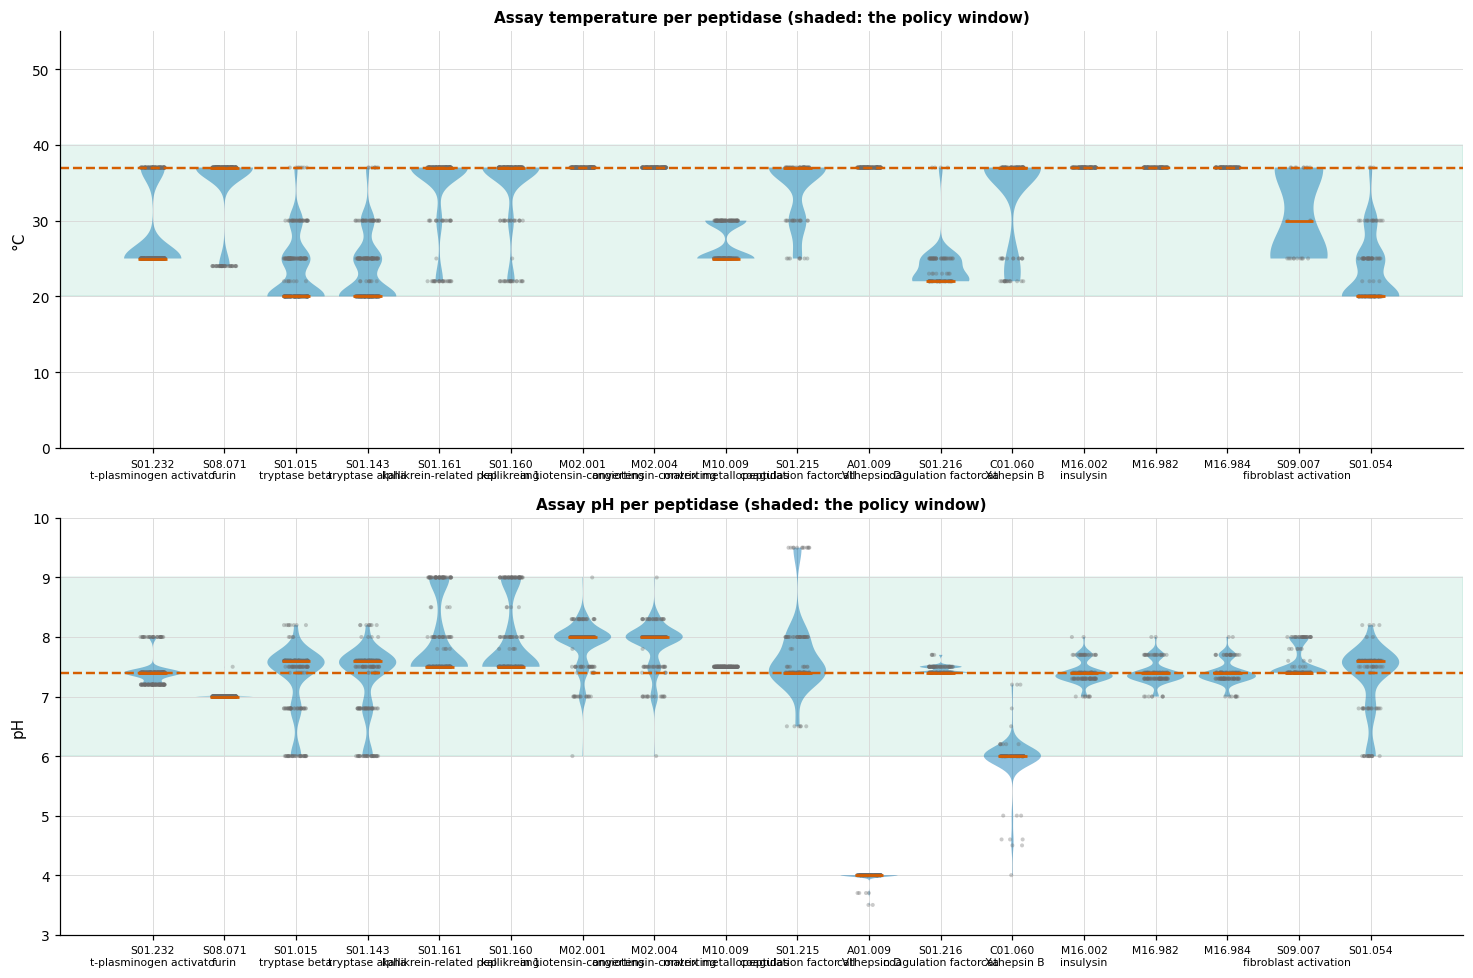

In [6]:
per_protease = exploded.groupby("merops_code").agg(
    entries=("value_numeric", "size"),
    temperature_median=("temperature_c", "median"),
    temperature_min=("temperature_c", "min"),
    temperature_max=("temperature_c", "max"),
    distinct_temperatures=("temperature_c", "nunique"),
    ph_median=("ph", "median"),
    ph_min=("ph", "min"),
    ph_max=("ph", "max"),
    distinct_ph=("ph", "nunique"),
    mutant_share=("is_mutant", "mean"),
    references=("reference_ids", "nunique"),
)
per_protease["temperature_range"] = per_protease["temperature_max"] - per_protease["temperature_min"]
per_protease["ph_range"] = per_protease["ph_max"] - per_protease["ph_min"]
per_protease["merops_cleavages"] = per_protease.index.map(merops_counts)
per_protease["name"] = per_protease.index.map(names)
measured = per_protease[per_protease["entries"] >= MIN_ENTRIES_FOR_SUMMARY]

print(f"codes with at least {MIN_ENTRIES_FOR_SUMMARY} entries: {len(measured)}")
print("\nwithin-code temperature range (K):")
print(measured["temperature_range"].describe()[["50%", "75%", "max"]].round(1).to_string())
print(f"  codes spanning at least 12 K: {int((measured['temperature_range'] >= 12).sum())}")
print("\nwithin-code pH range (units):")
print(measured["ph_range"].describe()[["50%", "75%", "max"]].round(2).to_string())
print(f"  codes spanning at least 1.5 units: {int((measured['ph_range'] >= 1.5).sum())}")

with_conditions = exploded[exploded["temperature_c"].notna() | exploded["ph"].notna()]
selected = list(with_conditions.groupby("merops_code").size().sort_values(ascending=False).head(N_VIOLIN_PROTEASES).index)
labels = [f"{code}\n{str(names.get(code, ''))[:22]}" for code in selected]

fig, axes = plt.subplots(2, 1, figsize=(13.5, 9.0))
for ax, column, reference, title, limits, policy in (
    (axes[0], "temperature_c", REFERENCE_TEMPERATURE_C, "Assay temperature per peptidase", (0, 55), TEMPERATURE_POLICY_C),
    (axes[1], "ph", 7.4, "Assay pH per peptidase", (3, 10), PH_POLICY),
):
    data, positions = [], []
    for position, code in enumerate(selected):
        values = with_conditions.loc[with_conditions["merops_code"] == code, column].dropna().to_numpy()
        if len(values) >= 2 and np.ptp(values) > 0:
            data.append(values)
            positions.append(position)
        if len(values):
            ax.scatter(
                np.full(len(values), position) + np.random.default_rng(position).uniform(-0.17, 0.17, len(values)),
                values, s=7, color=common.NEUTRAL, alpha=0.35, edgecolor="none", zorder=2,
            )
    if data:
        parts = ax.violinplot(data, positions=positions, widths=0.8, showextrema=False, showmedians=True)
        for body in parts["bodies"]:
            body.set_facecolor(common.CATEGORICAL_COLORS[0])
            body.set_alpha(0.45)
        parts["cmedians"].set_color(common.CATEGORICAL_COLORS[1])
        parts["cmedians"].set_linewidth(1.8)
    ## The policy band, so the exclusion rule is visible against the data it acts on
    ax.axhspan(policy[0], policy[1], color=common.CATEGORICAL_COLORS[2], alpha=0.10, zorder=0)
    ax.axhline(reference, color=common.CATEGORICAL_COLORS[1], linestyle="--", linewidth=1.6)
    ax.set_xticks(range(len(selected)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylim(*limits)
    ax.set_ylabel("°C" if column == "temperature_c" else "pH")
    ax.set_title(f"{title} (shaded: the policy window)", fontsize=10)
fig.tight_layout()
plt.show()

**Provenance**

The input is BRENDA 2026.1 `data/serum_proteolysis_calibration/processed/kinetics/brenda_all_peptidases.parquet`, produced by `assets/scripts/downloads/serum_proteolysis_calibration/ingest_brenda.py` from the licensed JSON archive. Code cells 4–10 parse `comment_raw` for temperature, pH and mutant status, then explode semicolon-separated MEROPS codes; one plotted row is a mapped parameter entry, so one original BRENDA measurement may appear under several codes. `results/0_11_condition_coverage.csv` reports pH in 5,715 entries (68.3%), strict temperature in 5,346 (63.9%), and 1,617 mutant flags (19.3%). Check the `comment_raw` examples in code cell 6, the regexes in cell 3, and `results/0_11_annotated_entries.csv`. These fields are extracted from prose rather than curated structured assay metadata; absent values mean unknown conditions.


### Reading the figure

A peptidase whose points collapse onto one horizontal line was measured at a
single condition; one with two or three bands was measured at that many distinct
conditions by different groups. The cathepsins are the clearest pH outliers and
they are not errors: an acidic optimum is the correct physiological condition for
a lysosomal enzyme, which makes those rows correct kinetics for a compartment
that is not serum.

In [7]:
print(
    measured.loc[selected, ["name", "entries", "temperature_median", "distinct_temperatures", "ph_median", "distinct_ph", "mutant_share"]]
    .round(2)
    .to_string()
)

                                                       name  entries  temperature_median  distinct_temperatures  ph_median  distinct_ph  mutant_share
merops_code                                                                                                                                          
S01.232                             t-plasminogen activator      389                25.0                      2        7.4            3          0.20
S08.071                                               furin      306                37.0                      2        7.0            2          0.00
S01.015                                       tryptase beta      320                20.0                      5        7.6            7          0.09
S01.143                                      tryptase alpha      320                20.0                      5        7.6            7          0.09
S01.161                      kallikrein-related peptidase 2      242                37.0            

## What a temperature correction could be worth

The rate constant follows the Arrhenius form,

$$k(T) = A \exp\!\left(-\frac{E_a}{RT}\right),
  \qquad
  \frac{k(T_2)}{k(T_1)} = \exp\!\left[\frac{E_a}{R}\left(\frac{1}{T_1}-\frac{1}{T_2}\right)\right],$$

and for $k_{cat}/K_M$ the barrier is the free energy of the transition state
relative to free enzyme plus free substrate, so the form applies with $E_a$ an
apparent activation energy of that composite. The data contain no per-enzyme
estimate, so three values spanning the enzymatic range are used.

$K_M$ would **not** be corrected by this form even if a correction were applied:
it behaves like an equilibrium constant, its temperature dependence follows van 't
Hoff with the enthalpy of binding, and that enthalpy is small and of either sign.

In [8]:
def arrhenius_factor(delta_kelvin: np.ndarray, activation_energy: float) -> np.ndarray:
    """Return the rate factor for a temperature offset from the reference.

    :param delta_kelvin: Offset from ``REFERENCE_TEMPERATURE_C``, in kelvin.
    :param activation_energy: Apparent activation energy in kJ/mol.
    :return: Multiplicative factor on the rate.
    """

    reference = REFERENCE_TEMPERATURE_C + 273.15
    other = reference + delta_kelvin
    return np.exp(activation_energy / GAS_CONSTANT_KJ * (1.0 / reference - 1.0 / other))


normalisation = pd.DataFrame(
    [
        {
            "activation_energy_kj_per_mol": energy,
            "implied_q10": float(arrhenius_factor(np.array([10.0]), energy)[0]),
            "factor_25C_to_37C": float(arrhenius_factor(np.array([-12.0]), energy)[0]),
            "median_within_code_factor": float(np.nanmedian(arrhenius_factor(measured["temperature_range"].to_numpy(), energy))),
        }
        for energy in ACTIVATION_ENERGIES_KJ
    ]
)
print(normalisation.round(2).to_string(index=False))

 activation_energy_kj_per_mol  implied_q10  factor_25C_to_37C  median_within_code_factor
                         30.0         1.44               0.63                       1.54
                         50.0         1.83               0.46                       2.06
                         70.0         2.33               0.34                       2.75


## Why a correction can only act on a minority of proteases

The statistic a correction is meant to sharpen is a **rank** correlation computed
**within** one protease. A Spearman correlation is invariant under any strictly
increasing transformation, and a temperature correction multiplying every
measurement of a protease by the same factor is exactly such a transformation. For
a protease measured at a single temperature the correction changes the rank
correlation by **precisely zero**, not approximately.

The question is therefore not how large the correction is but on how many
proteases the temperature varies within the substrate set.

In [9]:
## The substrates a protease contributes, counted from BRENDA alone
parses = [parse_substrate(text) for text in exploded["substrate_raw"]]
exploded["substrate_sequence"] = [parse.sequence for parse in parses]
exploded["has_window"] = [
    resolvable_subsites(parse) > 0 or (parse.is_fret and len(parse.sequence) >= MIN_FRET_LENGTH)
    for parse in parses
]
scoreable = exploded[exploded["has_window"]]

distinct = scoreable.dropna(subset=["temperature_c"]).groupby("merops_code")["temperature_c"].nunique()
per_substrate = scoreable.dropna(subset=["temperature_c"]).groupby(["merops_code", "substrate_raw"])["temperature_c"].median()
varies = per_substrate.groupby("merops_code").nunique()

print(f"proteases with a scoreable substrate and a temperature: {len(distinct)}")
print(f"  measured at exactly one temperature: {int((distinct == 1).sum())}")
print(f"  measured at two or more:             {int((distinct >= 2).sum())}")
print(f"  whose substrates differ in temperature, the only ones a correction can reorder: {int((varies >= 2).sum())}")
print("\ndistinct temperatures per protease:")
print(distinct.value_counts().sort_index().to_string())

proteases with a scoreable substrate and a temperature: 101
  measured at exactly one temperature: 55
  measured at two or more:             46
  whose substrates differ in temperature, the only ones a correction can reorder: 43

distinct temperatures per protease:
temperature_c
1    55
2    24
3    17
4     5


## The floor: replicate scatter at a fixed temperature

Whatever a correction is worth, it is bounded by the noise that remains after it.
Where two laboratories report the same parameter for the same enzyme on the same
substrate **at the same temperature**, their difference is what no condition
metadata can remove: buffer, ionic strength, enzyme preparation, substrate purity,
detection method and calibration.

replicate groups: 709 | at a single temperature: 677 | differing: 32
  median fold difference at one temperature: 5.2x
  upper quartile:                            33.6x
  median log10 spread, differing temperature: 0.92
  median log10 spread, same temperature:      0.72


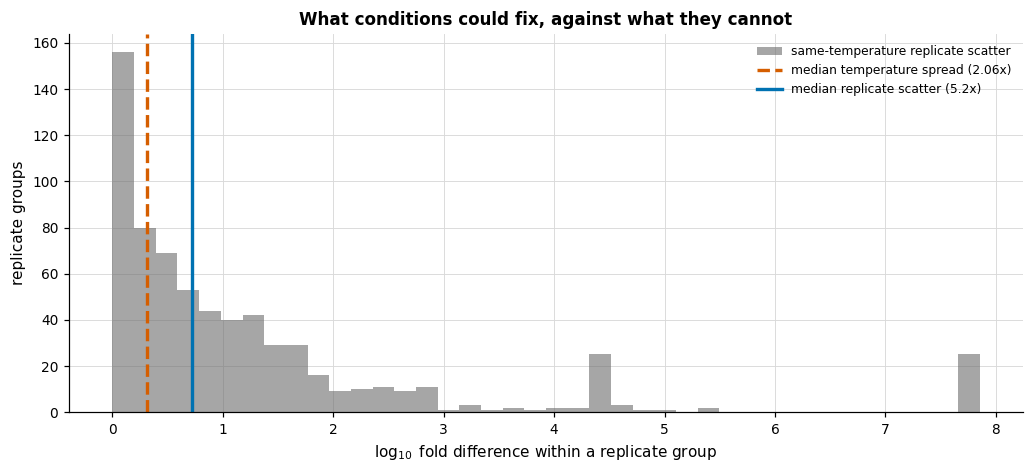

In [10]:
rates = exploded[exploded["parameter_type"].isin(["turnover_number", "kcat_km_value"])].dropna(subset=["temperature_c"])
groups = rates.groupby(["merops_code", "substrate_raw", "parameter_type"]).agg(
    n=("value_numeric", "size"),
    value_min=("value_numeric", "min"),
    value_max=("value_numeric", "max"),
    temperature_min=("temperature_c", "min"),
    temperature_max=("temperature_c", "max"),
    references=("reference_ids", "nunique"),
)
replicates = groups[groups["n"] >= 2].copy()
replicates["temperature_difference"] = replicates["temperature_max"] - replicates["temperature_min"]
replicates["log10_fold_spread"] = np.log10(replicates["value_max"] / replicates["value_min"])
same = replicates[replicates["temperature_difference"] == 0]
differing = replicates[replicates["temperature_difference"] > 0]

median_fold = 10 ** float(same["log10_fold_spread"].median())
upper_fold = 10 ** float(same["log10_fold_spread"].quantile(0.75))
print(f"replicate groups: {len(replicates)} | at a single temperature: {len(same)} | differing: {len(differing)}")
print(f"  median fold difference at one temperature: {median_fold:.1f}x")
print(f"  upper quartile:                            {upper_fold:.1f}x")
if len(differing):
    print(f"  median log10 spread, differing temperature: {differing['log10_fold_spread'].median():.2f}")
    print(f"  median log10 spread, same temperature:      {same['log10_fold_spread'].median():.2f}")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.hist(same["log10_fold_spread"], bins=40, color=common.NEUTRAL, alpha=0.6, label="same-temperature replicate scatter")
central = normalisation[normalisation["activation_energy_kj_per_mol"] == 50.0].iloc[0]
ax.axvline(np.log10(central["median_within_code_factor"]), color=common.CATEGORICAL_COLORS[1], linewidth=2.2,
           linestyle="--", label=f"median temperature spread ({central['median_within_code_factor']:.2f}x)")
ax.axvline(float(same["log10_fold_spread"].median()), color=common.CATEGORICAL_COLORS[0], linewidth=2.2,
           label=f"median replicate scatter ({median_fold:.1f}x)")
ax.set_xlabel(r"$\log_{10}$ fold difference within a replicate group")
ax.set_ylabel("replicate groups")
ax.set_title("What conditions could fix, against what they cannot")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

> **Caveat.** Physiological comparability materially changes the observed relationship. In `results/0_11_filter_comparison.csv`, pooled Spearman ρ is 0.328 for all 764 rows, 0.193 for the 451 rows restricted to 37 °C, and 0.235 for the 304 rows restricted to physiological pH. Serum calibration should not extrapolate the unrestricted correlation as if it held under human serum conditions. The table is a saved sensitivity result; this notebook does not regenerate it.


## How much of a matrix its own test substrates could account for

A MEROPS matrix is built from the cleavages that database records for a protease,
and MEROPS pools natural and synthetic substrates alike. If a BRENDA substrate is
also among those cleavages, the matrix is partly fitted to a sequence it will
later be asked to score.

**This cannot be checked directly.** The local MEROPS data retains aggregated
counts and not the cleavage sequences, so the intersection is not computable from
what is on disk. What is computable is a bound: if every scoreable BRENDA
substrate of a protease were also a MEROPS cleavage of it, the share of the matrix
those substrates could account for is the ratio of the two counts.

proteases with both counts: 101
  bound above 10%:  60
  bound above 100%, more measured substrates than cleavages in the matrix: 15

the worst cases:
                                                       name  brenda_substrates  merops_cleavages  leakage_bound
merops_code                                                                                                    
T01.015                           proteasome subunit beta5i                  5               1.0          5.000
T01.013                           proteasome subunit beta1i                  5               1.0          5.000
S09.007         fibroblast activation protein alpha subunit                 25               6.0          4.167
S01.232                             t-plasminogen activator                 35               9.0          3.889
S09.018                              dipeptidyl-peptidase 8                 23              10.0          2.300
S01.160                                        kallikrein 1      

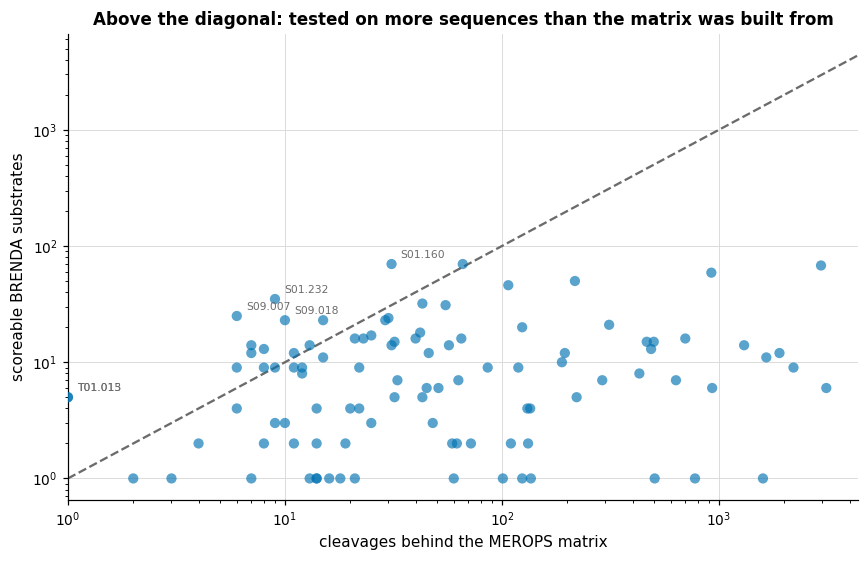

In [11]:
leakage = scoreable.groupby("merops_code").agg(brenda_substrates=("substrate_raw", "nunique"))
leakage["merops_cleavages"] = leakage.index.map(merops_counts)
leakage = leakage.dropna(subset=["merops_cleavages"])
leakage["leakage_bound"] = leakage["brenda_substrates"] / leakage["merops_cleavages"]
leakage["name"] = leakage.index.map(names)
leakage = leakage.sort_values("leakage_bound", ascending=False)

print(f"proteases with both counts: {len(leakage)}")
print(f"  bound above 10%:  {int((leakage['leakage_bound'] > 0.10).sum())}")
print(f"  bound above 100%, more measured substrates than cleavages in the matrix: "
      f"{int((leakage['leakage_bound'] > 1.0).sum())}")
print("\nthe worst cases:")
print(leakage.head(8)[["name", "brenda_substrates", "merops_cleavages", "leakage_bound"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.scatter(leakage["merops_cleavages"], leakage["brenda_substrates"], s=45,
           color=common.CATEGORICAL_COLORS[0], alpha=0.65, edgecolor="none", zorder=3)
for code, row in leakage.head(6).iterrows():
    ax.annotate(code, (row["merops_cleavages"], row["brenda_substrates"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7, color=common.NEUTRAL)
limits = (1, max(leakage["merops_cleavages"].max(), leakage["brenda_substrates"].max()) * 1.4)
ax.plot(limits, limits, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*limits)
ax.set_xlabel("cleavages behind the MEROPS matrix")
ax.set_ylabel("scoreable BRENDA substrates")
ax.set_title("Above the diagonal: tested on more sequences than the matrix was built from")
fig.tight_layout()
plt.show()

## The policy, and the table it produces

The policy is **temperature 20–40 °C, pH 6–9**, both deliberately wide. Entries
outside are removed rather than rescaled. Entries whose condition the comment does
not state are kept, because a missing annotation is not evidence of an extreme
condition; the alternative would discard a third of the table on the strength of
BRENDA's formatting.

The annotated table written here is what `0_15` consumes, so the policy is applied
once, at the point where the conditions are known, and not re-derived downstream.

                       rule  entries
 entries with a MEROPS code    12341
         temperature stated     8133
temperature outside 20-40 C       20
                  pH stated     9099
             pH outside 6-9     1001
      removed by the policy     1021

the rejected mass, by protease:
             entries                     name
merops_code                                  
A01.009          150              cathepsin D
I29.001           79                         
C01.032           79              cathepsin L
C01.034           75              cathepsin S
I29.004           75                         
I29.007           62                         
C01.036           62              cathepsin K
S53.003           54  tripeptidyl-peptidase I
I29.010           48                         
C01.009           48              cathepsin V


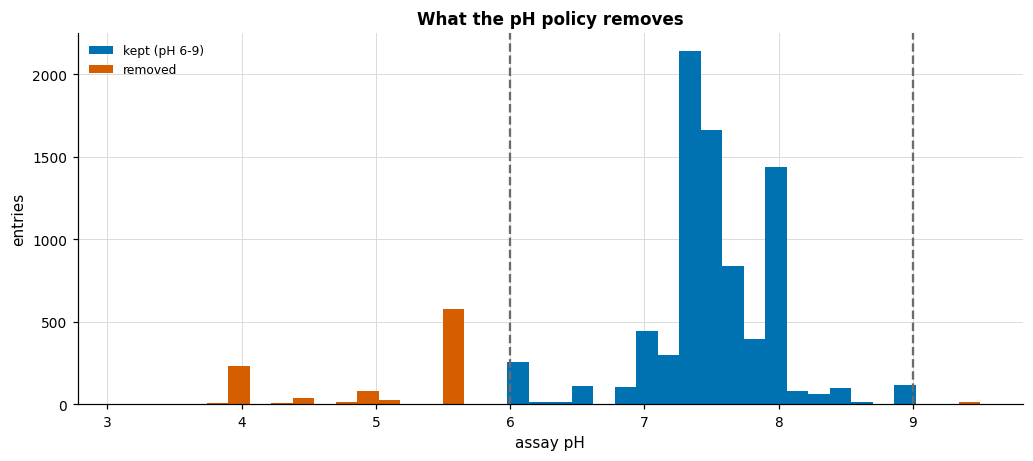

In [12]:
temperature_ok = exploded["temperature_c"].isna() | exploded["temperature_c"].between(*TEMPERATURE_POLICY_C)
ph_ok = exploded["ph"].isna() | exploded["ph"].between(*PH_POLICY)
exploded["passes_condition_policy"] = temperature_ok & ph_ok

policy = pd.DataFrame(
    {
        "rule": [
            "entries with a MEROPS code",
            "temperature stated",
            f"temperature outside {TEMPERATURE_POLICY_C[0]:.0f}-{TEMPERATURE_POLICY_C[1]:.0f} C",
            "pH stated",
            f"pH outside {PH_POLICY[0]:.0f}-{PH_POLICY[1]:.0f}",
            "removed by the policy",
        ],
        "entries": [
            len(exploded),
            int(exploded["temperature_c"].notna().sum()),
            int((~temperature_ok).sum()),
            int(exploded["ph"].notna().sum()),
            int((~ph_ok).sum()),
            int((~exploded["passes_condition_policy"]).sum()),
        ],
    }
)
print(policy.to_string(index=False))

removed_by_ph = exploded.loc[~ph_ok].groupby("merops_code").size().sort_values(ascending=False).head(10)
print("\nthe rejected mass, by protease:")
print(pd.DataFrame({"entries": removed_by_ph, "name": [names.get(c, "") for c in removed_by_ph.index]}).to_string())

fig, ax = plt.subplots(figsize=(9.5, 4.3))
stated = exploded.dropna(subset=["ph"])
ax.hist(
    [stated.loc[stated["ph"].between(*PH_POLICY), "ph"], stated.loc[~stated["ph"].between(*PH_POLICY), "ph"]],
    bins=40, stacked=True,
    color=[common.CATEGORICAL_COLORS[0], common.CATEGORICAL_COLORS[1]],
    label=[f"kept (pH {PH_POLICY[0]:.0f}-{PH_POLICY[1]:.0f})", "removed"],
)
for bound in PH_POLICY:
    ax.axvline(bound, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.set_xlabel("assay pH")
ax.set_ylabel("entries")
ax.set_title("What the pH policy removes")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

**Provenance**

Code cell 24 applies `_analysis_common.py:apply_condition_policy` to the BRENDA rows: inclusive 20–40 °C and pH 6–9; missing temperature or pH is retained. The counting unit is an exploded MEROPS-code row, not a unique assay. `results/0_11_condition_policy.csv` records removals by condition and `results/0_11_condition_coverage.csv` records missingness; inspect both alongside `results/0_11_annotated_entries.csv` for exact rows. BRENDA values remain in their original parameter-specific units in this notebook; the policy is a comparability filter, not a conversion to physiological rates.

> **Caveat.** Approximately one third of entries lack pH or temperature metadata and pass because missing conditions are retained. `_analysis_common.py:90` sets `EXCLUDE_MUTANT_ENZYMES = False` although its preceding comment says mutant measurements describe a different protein; 1,617 entries (19.3%) are flagged mutant in `results/0_11_condition_coverage.csv`. The filter therefore does not guarantee wild-type, physiological measurements.


> **Caveat.** The analysis README says the decision was to exclude nothing on condition grounds, whereas `apply_condition_policy` in `_analysis_common.py` rejects stated out-of-range values. `results/0_15_assembly_losses.csv` records 3,773 → 3,752 baseline and 8,308 → 7,619 extended numeric rows after this policy. These are actual exclusions despite missing values being retained.


In [13]:
annotated = exploded[
    [
        "merops_code", "ec_number", "substrate_raw", "parameter_type", "value_numeric", "unit_raw",
        "temperature_c", "ph", "is_mutant", "reference_ids", "protein_ids", "pmids",
        "has_window", "excluded_as_outlier", "passes_condition_policy",
    ]
]
common.save_result(coverage, "0_11_condition_coverage.csv")
common.save_result(per_protease.reset_index(), "0_11_condition_per_protease.csv")
common.save_result(outliers, "0_11_outliers.csv")
common.save_result(replicates.reset_index(), "0_11_replicate_scatter.csv")
common.save_result(normalisation, "0_11_normalisation.csv")
common.save_result(policy, "0_11_condition_policy.csv")
common.save_result(leakage.reset_index(), "0_11_leakage_bound.csv")
common.save_result(annotated, "0_11_annotated_entries.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_11_annotated_entries.csv')

## Findings and decisions

**The conditions are recoverable and they differ by enough to matter.** pH parses
for roughly two thirds of the entries and temperature for a similar share, and
about a fifth of entries are mutant enzymes, which is a mismatch of object rather
than of condition since a MEROPS matrix describes the wild type.

**The earlier "extreme temperatures" were a parsing bug.** After the strict
pattern the plausibility rule rejects nothing, which is the cleanest possible
statement that the outliers were an artefact of reading mutation codes as
temperatures.

**A temperature correction is computable and small where it applies at all.** At
an apparent activation energy near 50 kJ/mol the median within-protease
temperature span implies a rate factor around two, while the irreducible
between-laboratory scatter at a fixed temperature has a median several-fold and an
upper quartile of an order of magnitude. The correction would remove a term
sitting inside a larger noise floor, using a constant the data do not contain.
Beyond that, most proteases are measured at a single temperature, and for those a
multiplicative correction changes a rank correlation by exactly zero.

**pH is excluded rather than corrected, and its outliers are not errors.** The
activity profile is bell-shaped with enzyme-specific ionisation constants and
cannot be inverted from one measurement. The rejected mass is not scattered: it
belongs to lysosomal enzymes whose acidic optimum is correct physiology for their
own compartment and wrong for a serum model. That is the stronger reason to
exclude them — not that the measurements are noisy, but that they measure a
different compartment.

**What this notebook deliberately does not decide.** Whether the policy sharpens
the relation between score and rate is a question about the relation, and it is
asked in series 2 on the datasets `0_15` assembles. Keeping it out of here is what
makes this notebook depend on BRENDA and MEROPS alone.